In [31]:
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = True
from cmcrameri import cm
from sklearn.linear_model import LinearRegression
from scipy.interpolate import griddata
import numpy as np
from matplotlib.ticker import FixedLocator
from matplotlib.lines import Line2D

In [32]:
data_dir = '~/Desktop/Data/'

In [33]:
#read in galaxia results
galaxia = pd.read_csv(data_dir+'galaxia_output.asc',sep='\s+',header=None,skiprows=1,names=['numax','gmag','dist_kpc','Pop'])
galaxia = galaxia[(galaxia['numax']>3) & (galaxia['numax']<280)] #limit to our frequency range

#sep into population
halo=galaxia[galaxia['Pop']==8]
not_halo = galaxia[galaxia['Pop']<8] 


In [34]:
cs = pd.read_csv('../data/true_sources_final.csv')
unconfirmed = pd.read_csv('../data/unconfirmed.csv')
limit = pd.read_csv(data_dir+'kep_limit_estimate.csv')

30 kpc: annotating at (14.86, 0.535)
40 kpc: annotating at (15.89, 0.535)
60 kpc: annotating at (16.98, 0.535)
80 kpc: annotating at (17.68, 0.535)
100 kpc: annotating at (18.39, 0.535)


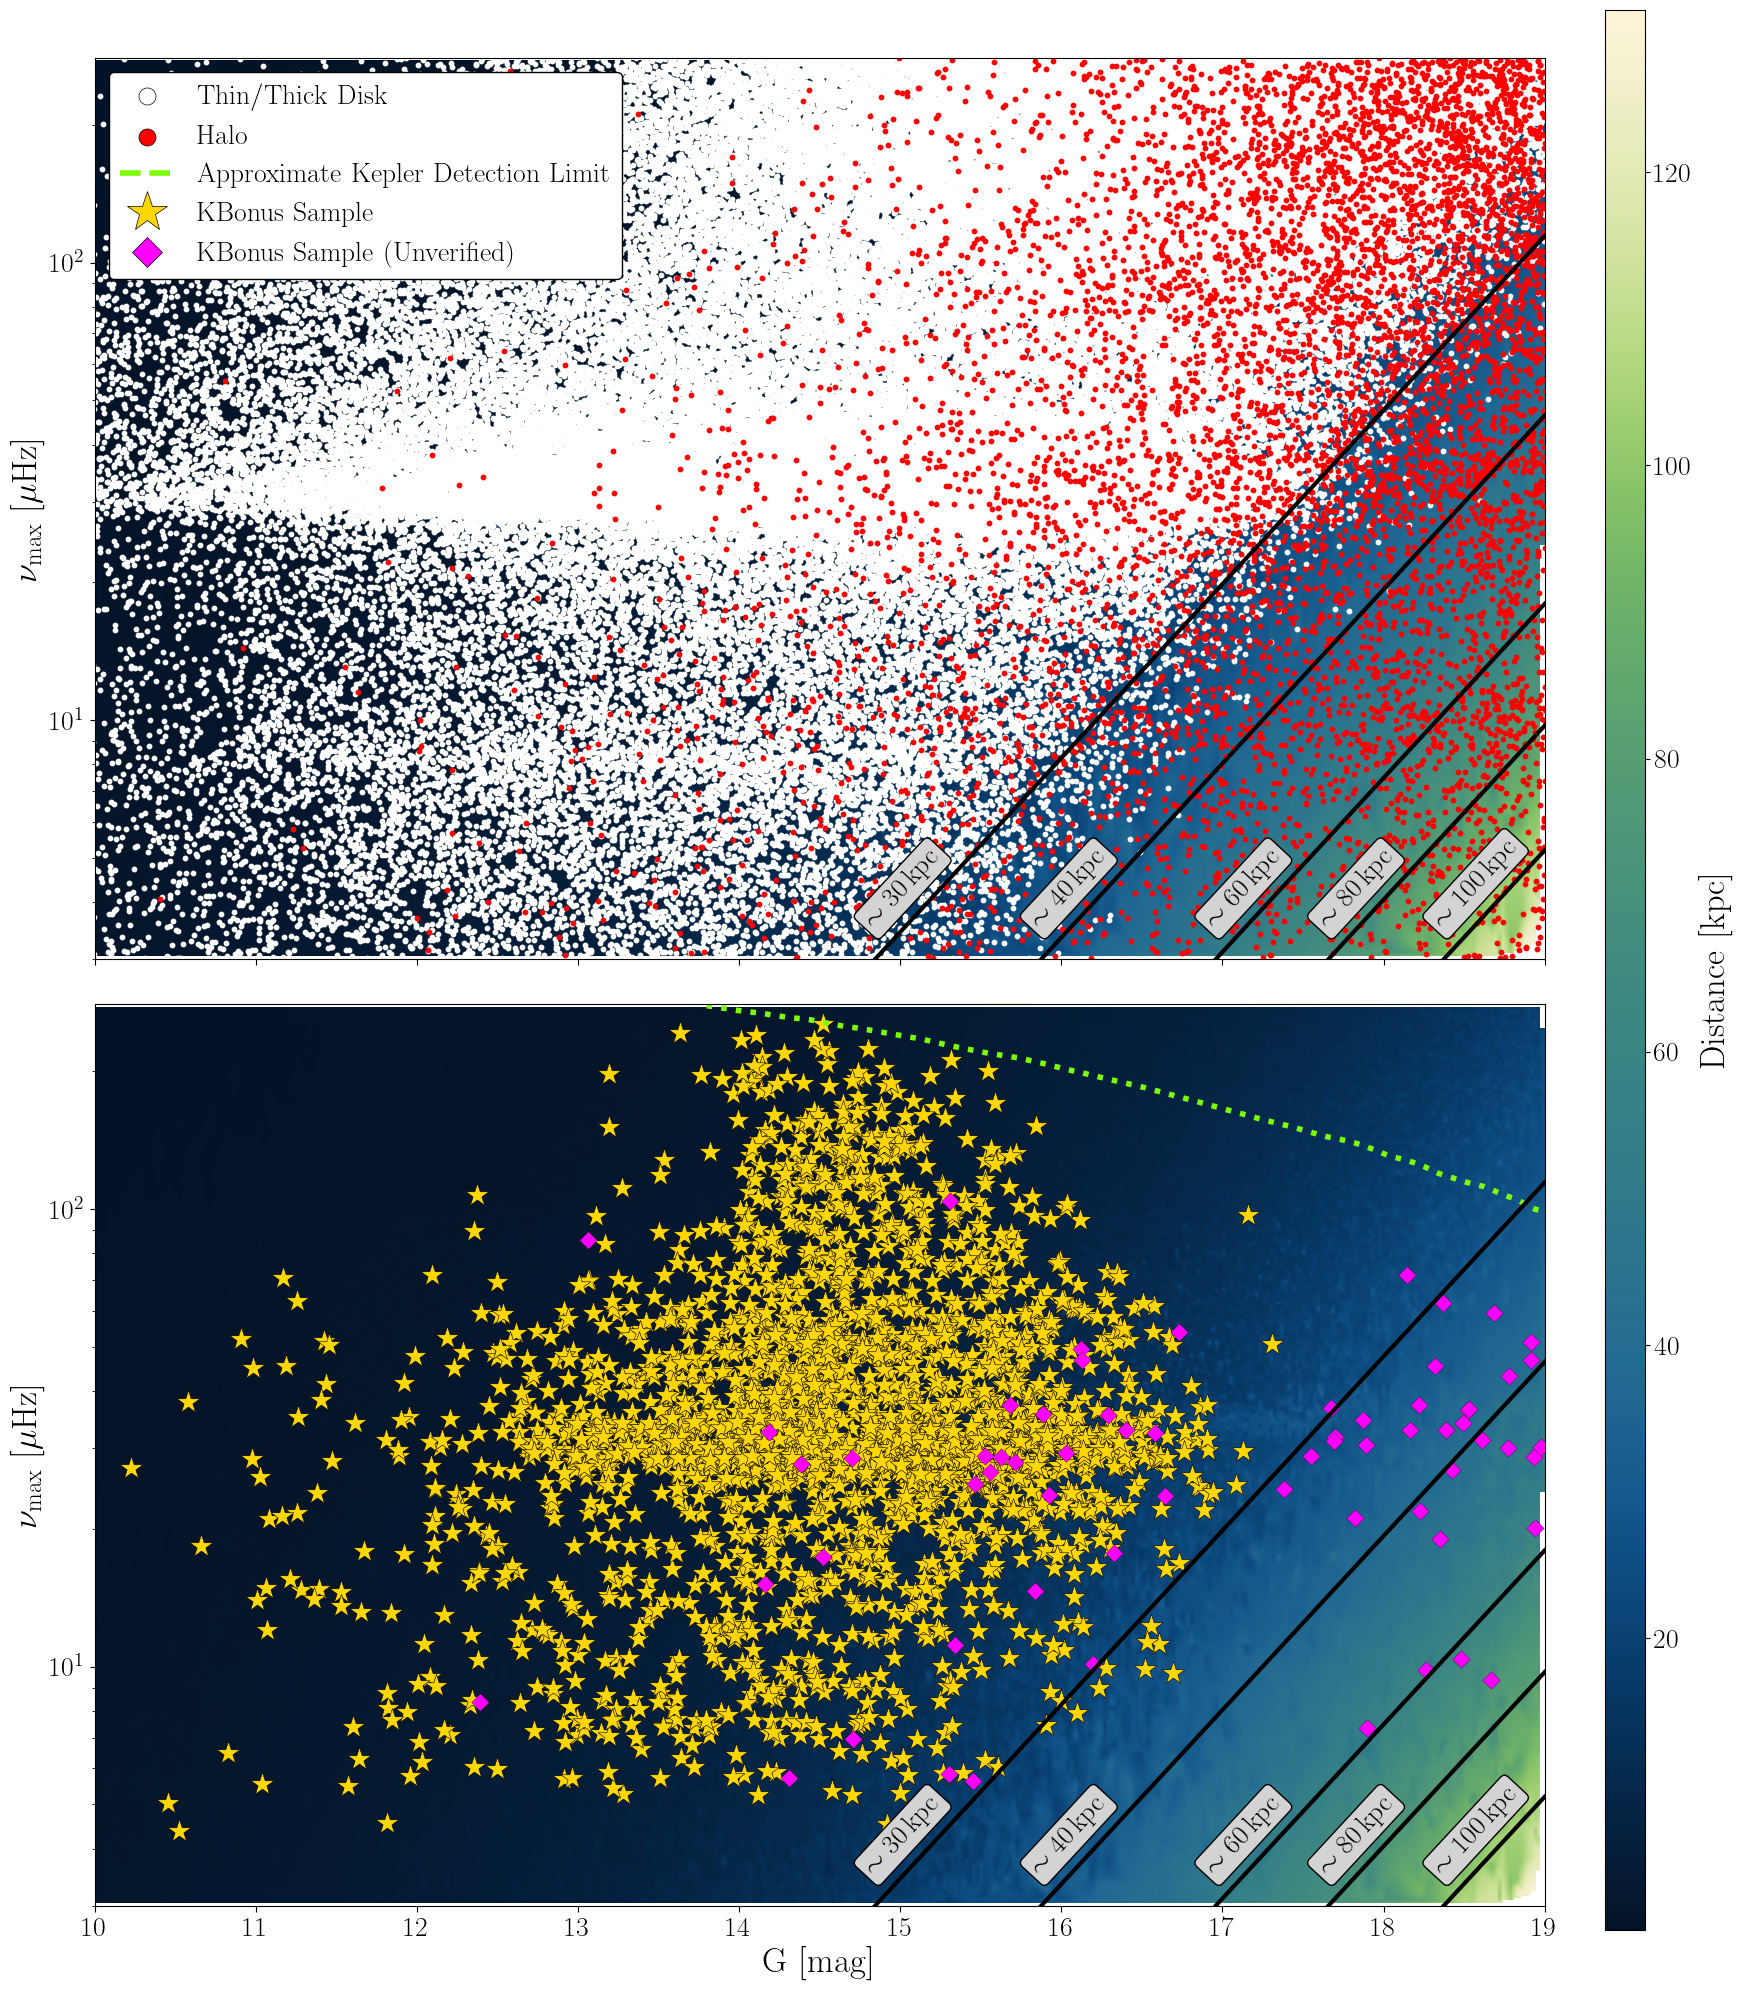

In [35]:
fig, axes = plt.subplots(2, 1, figsize=(20, 24), sharex=True, sharey=True)

# --- shared grid parameters ---
x = galaxia['gmag'].values
y = np.log10(galaxia['numax'].values)
z = galaxia['dist_kpc'].values
xmin, xmax = 10, max(x)
ymin, ymax = np.log10(3), np.log10(280)
xi = np.linspace(xmin, xmax, 400)
yi = np.linspace(ymin, ymax, 400)
Xi, Yi = np.meshgrid(xi, yi)
Zi = griddata((x, y), z, (Xi, Yi), method='linear')

vmin, vmax = z.min(), z.max()
yticks = np.arange(np.floor(ymin), np.ceil(ymax) + 1)

# --- top subplot ---
ax = axes[0]
im = ax.imshow(
    Zi, origin='lower', extent=[xmin, xmax, ymin, ymax],
    aspect='auto', cmap=cm.navia, vmin=vmin, vmax=vmax, interpolation='bilinear'
)
ax.scatter(not_halo['gmag'], np.log10(not_halo['numax'].values), s=10, color='white', label='$\mathrm{Thin/Thick\,\, Disk}$',rasterized=True)
ax.scatter(halo['gmag'], np.log10(halo['numax'].values), s=10, color='red', label='$\mathrm{Halo}$',rasterized=True)
ax.set_yticks(yticks)
ax.set_yticklabels([f'$10^{{{int(t)}}}$' for t in yticks],fontsize=20)
ax.set_ylabel('$\mathrm{\\nu_{max}\,\,[\mu Hz]}$', fontsize=25)
ax.set_ylim(ymin, ymax)
ax.set_xlim(xmin, xmax)

# --- bottom subplot ---
ax = axes[1]
ax.imshow(
    Zi, origin='lower', extent=[xmin, xmax, ymin, ymax],
    aspect='auto', cmap=cm.navia, vmin=vmin, vmax=vmax, interpolation='bilinear'
)
ax.scatter(cs['phot_g_mean_mag'], np.log10(cs['numax']), c='gold', marker='*',edgecolor='black',linewidth=0.4,s=300,rasterized=True)
ax.scatter(unconfirmed['phot_g_mean_mag'],np.log10(unconfirmed['numax']),c='magenta',marker='D',s=80,edgecolor='black',linewidth=0.2,rasterized=True)
ax.plot(limit['mag']+0.7,np.log10(limit['numax'].values),color='lawngreen',linestyle=':',linewidth=4,label='$\mathrm{Approximate \,\,Kepler \,\,Detection\,\, Limit}$')
ax.set_yticks(yticks)
ax.set_yticklabels([f'$10^{{{int(t)}}}$' for t in yticks],fontsize=20)
ax.set_ylabel('$\mathrm{\\nu_{max}\,\,[\mu Hz]}$', fontsize=25)
ax.set_xlabel('$\mathrm{G\,\,[mag]}$', fontsize=25)
ax.set_ylim(ymin, ymax)
ax.set_xlim(xmin, xmax)

# --- single shared colorbar ---
fig.subplots_adjust(right=0.85, hspace=0.05)
cbar_ax = fig.add_axes([0.88, 0.1, 0.02, 0.8])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('$\mathrm{Distance \,\,[kpc]}$', fontsize=25)
cbar.ax.tick_params(labelsize=20)

# Minor ticks
minor_ticks_linear = np.concatenate([
    np.arange(1, 10, 1),
    np.arange(10, 100, 10),
    np.arange(100, 300, 100),
])
minor_ticks_log = np.log10(minor_ticks_linear)
minor_ticks_log = minor_ticks_log[(minor_ticks_log >= ymin) & (minor_ticks_log <= ymax)]

for ax in axes:
    ax.yaxis.set_minor_locator(FixedLocator(minor_ticks_log))
    ax.tick_params(axis='y', which='minor', length=2, color='black')
    ax.tick_params(axis='x', which='major', length=4, color='black')
ax.tick_params(axis='x', labelsize=20)
for ax in axes:
    ax.yaxis.set_minor_locator(FixedLocator(minor_ticks_log))
    ax.tick_params(axis='y', which='minor', length=2, color='black')

# --- fit lines at every ~10 kpc using shared slope ---
# --- fit lines at every ~10 kpc, independent fit per distance ---
x_line = np.array([xmin, xmax])

mask30 = np.abs(z - 30) < 5
mask40 = np.abs(z - 40) < 5
x30, y30 = x[mask30], y[mask30]
x40, y40 = x[mask40], y[mask40]
x_all = np.concatenate([x30, x40]).reshape(-1, 1)
y_all = np.concatenate([y30, y40])
reg = LinearRegression().fit(x_all, y_all)
shared_slope = reg.coef_[0]

distance_targets = [30, 40, 60, 80,100]

intercepts = {}
for dist in distance_targets:
    mask = np.abs(z - dist) < 5
    if mask.sum() < 10:
        continue
    intercept = np.mean(y[mask]) - shared_slope * np.mean(x[mask])
    intercepts[dist] = intercept
    y_line = shared_slope * x_line + intercept
    for ax in axes:
        ax.plot(x_line, y_line, color='black', linewidth=3)

fig.canvas.draw()

def get_line_angle_deg(ax, slope_data, x0, y0):
    p1 = ax.transData.transform((x0, y0))
    p2 = ax.transData.transform((x0 + 1.0, y0 + slope_data))
    dx, dy = p2[0] - p1[0], p2[1] - p1[1]
    return np.degrees(np.arctan2(dy, dx))

for dist, intercept in intercepts.items():
    # Find x where the line crosses ymin — place label just above that
    x_entry = (ymin - intercept) / shared_slope
    annot_x = x_entry + 0.02  # nudge slightly right of entry point
    annot_y = shared_slope * annot_x + intercept+0.05

    # If entry point is beyond xmax, skip
    if annot_x > xmax or annot_x < xmin:
        print(f'{dist} kpc: entry x={x_entry:.2f} out of plot range, skipping')
        continue

    print(f'{dist} kpc: annotating at ({annot_x:.2f}, {annot_y:.3f})')
    for ax in axes:
        angle = get_line_angle_deg(ax, shared_slope, annot_x, annot_y)
        ax.text(
            annot_x, annot_y,
            f'$\\sim{dist}\\,\\mathrm{{kpc}}$',
            fontsize=20,
            color='black',
            fontweight='bold',
            ha='left',
            va='bottom',
            rotation=angle,
            rotation_mode='anchor',
            zorder=10,
            bbox=dict(boxstyle='round,pad=0.2', fc='lightgrey', alpha=1,edgecolor='black')
        )
        
# --- legend (no distance lines) ---
legend_elements = [
    axes[0].scatter([], [], s=150, color='white', label='$\mathrm{Thin/Thick\,\, Disk}$'),
    axes[0].scatter([], [], s=150, color='red', label='$\mathrm{Halo}$'),
    Line2D([0],[0],color='lawngreen',linestyle='--',linewidth=4,label='$\mathrm{Approximate \,\,Kepler \,\,Detection\,\, Limit}$'),
    Line2D([0], [0], marker='*', color='w', markerfacecolor='gold', markeredgecolor='black',
           markeredgewidth=0.5, markersize=30, linestyle='None', label='$\mathrm{KBonus\,\,Sample}$'),
    Line2D([0],[0], marker='D',color='w',markerfacecolor='magenta',markeredgecolor='black',markeredgewidth=0.5,markersize=15,linestyle='None', label='$\mathrm{KBonus\,\,Sample\,\,(Unverified)}$')
]

legend = axes[0].legend(handles=legend_elements, fontsize=20, loc='upper left', facecolor='white', framealpha=1,edgecolor='black')

for handle in legend.legend_handles:
    if hasattr(handle, 'set_edgecolor'):
        handle.set_edgecolor('black')
        handle.set_linewidth(0.5)
plt.savefig('../figures/galaxia.pdf', format='pdf', bbox_inches='tight')

In [36]:
import numpy as np
from scipy.interpolate import LinearNDInterpolator, NearestNDInterpolator

# Clean the reference dataframe
train = galaxia[["numax", "gmag", "dist_kpc"]].replace(
    [np.inf, -np.inf], np.nan
).dropna()

train = train[train["numax"] > 0]

# Coordinates for interpolation
train_xy = np.column_stack([
    train["gmag"],
    np.log10(train["numax"])
])

# Linear interpolation inside the galaxia range
linear_interp = LinearNDInterpolator(
    train_xy,
    train["dist_kpc"],
    fill_value=np.nan
)

# Nearest-neighbour fallback for points outside the interpolation region
nearest_interp = NearestNDInterpolator(
    train_xy,
    train["dist_kpc"]
)

# Prepare unconfirmed stars
unconfirmed = unconfirmed.copy()

valid = (
    unconfirmed["numax"].notna()
    & unconfirmed["phot_g_mean_mag"].notna()
    & (unconfirmed["numax"] > 0)
)

xy_unconfirmed = np.column_stack([
    unconfirmed.loc[valid, "phot_g_mean_mag"],
    np.log10(unconfirmed.loc[valid, "numax"])
])

# Estimate distances
distance_est = linear_interp(xy_unconfirmed)

# Use nearest galaxia star where linear interpolation is unavailable
outside_range = np.isnan(distance_est)
distance_est[outside_range] = nearest_interp(xy_unconfirmed[outside_range])

# Add estimates to the dataframe
unconfirmed.loc[valid, "dist_kpc_est"] = distance_est
unconfirmed.loc[~valid, "dist_kpc_est"] = np.nan

30 kpc: annotating at (14.86, 0.535)
40 kpc: annotating at (15.89, 0.535)
60 kpc: annotating at (16.98, 0.535)
80 kpc: annotating at (17.68, 0.535)
100 kpc: annotating at (18.39, 0.535)


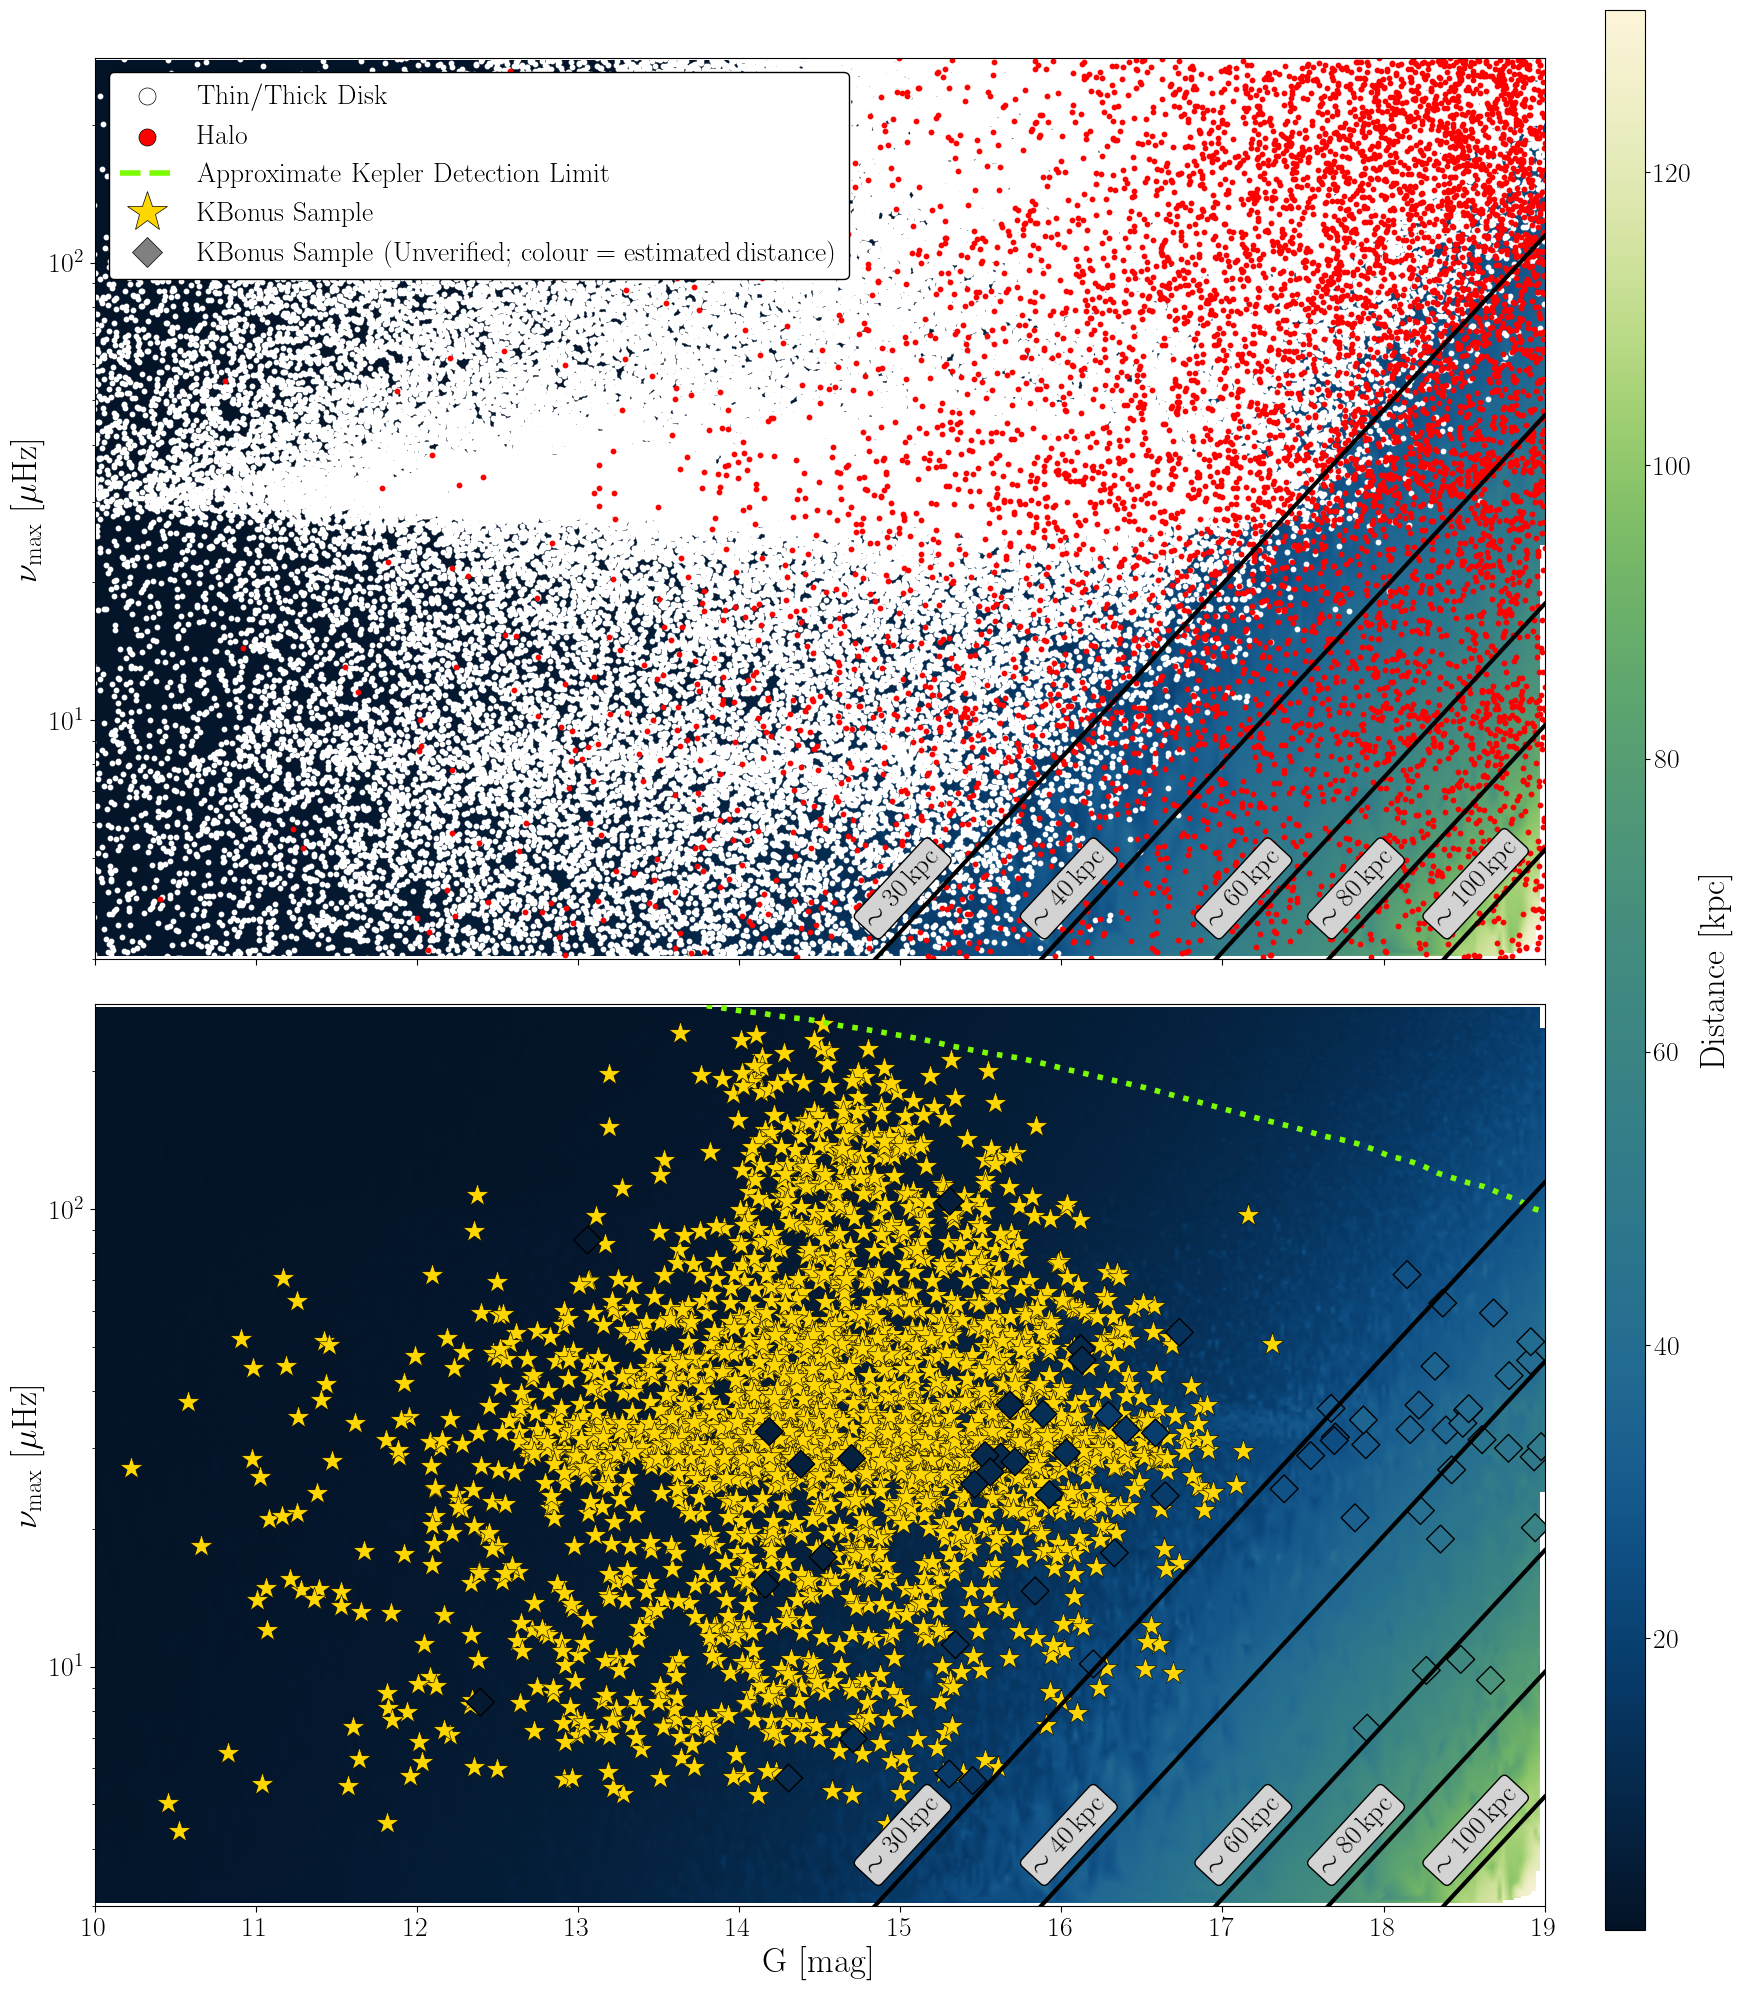

In [37]:
fig, axes = plt.subplots(2, 1, figsize=(20, 24), sharex=True, sharey=True)

# --- shared grid parameters ---
x = galaxia['gmag'].values
y = np.log10(galaxia['numax'].values)
z = galaxia['dist_kpc'].values
xmin, xmax = 10, max(x)
ymin, ymax = np.log10(3), np.log10(280)
xi = np.linspace(xmin, xmax, 400)
yi = np.linspace(ymin, ymax, 400)
Xi, Yi = np.meshgrid(xi, yi)
Zi = griddata((x, y), z, (Xi, Yi), method='linear')

vmin, vmax = z.min(), z.max()
yticks = np.arange(np.floor(ymin), np.ceil(ymax) + 1)

# --- top subplot ---
ax = axes[0]
im = ax.imshow(
    Zi, origin='lower', extent=[xmin, xmax, ymin, ymax],
    aspect='auto', cmap=cm.navia, vmin=vmin, vmax=vmax, interpolation='bilinear'
)
ax.scatter(not_halo['gmag'], np.log10(not_halo['numax'].values), s=10, color='white', label='$\mathrm{Thin/Thick\,\, Disk}$',rasterized=True)
ax.scatter(halo['gmag'], np.log10(halo['numax'].values), s=10, color='red', label='$\mathrm{Halo}$',rasterized=True)
ax.set_yticks(yticks)
ax.set_yticklabels([f'$10^{{{int(t)}}}$' for t in yticks],fontsize=20)
ax.set_ylabel('$\mathrm{\\nu_{max}\,\,[\mu Hz]}$', fontsize=25)
ax.set_ylim(ymin, ymax)
ax.set_xlim(xmin, xmax)

# --- bottom subplot ---
ax = axes[1]
ax.imshow(
    Zi, origin='lower', extent=[xmin, xmax, ymin, ymax],
    aspect='auto', cmap=cm.navia, vmin=vmin, vmax=vmax, interpolation='bilinear'
)
ax.scatter(cs['phot_g_mean_mag'], np.log10(cs['numax']), c='gold', marker='*',edgecolor='black',linewidth=0.4,s=300,rasterized=True)
# Keep only valid unconfirmed points
unconfirmed_plot = unconfirmed[
    unconfirmed["phot_g_mean_mag"].notna()
    & unconfirmed["numax"].notna()
    & unconfirmed["dist_kpc_est"].notna()
    & (unconfirmed["numax"] > 0)
].copy()

ax.scatter(
    unconfirmed_plot["phot_g_mean_mag"],
    np.log10(unconfirmed_plot["numax"]),
    c=unconfirmed_plot["dist_kpc_est"],
    cmap=im.cmap,
    norm=im.norm,          # exactly the same colour scale as the background
    marker="D",
    s=200,
    edgecolor="black",
    linewidth=1,
    rasterized=True
)
ax.plot(limit['mag']+0.7,np.log10(limit['numax'].values),color='lawngreen',linestyle=':',linewidth=4,label='$\mathrm{Approximate \,\,Kepler \,\,Detection\,\, Limit}$')
ax.set_yticks(yticks)
ax.set_yticklabels([f'$10^{{{int(t)}}}$' for t in yticks],fontsize=20)
ax.set_ylabel('$\mathrm{\\nu_{max}\,\,[\mu Hz]}$', fontsize=25)
ax.set_xlabel('$\mathrm{G\,\,[mag]}$', fontsize=25)
ax.set_ylim(ymin, ymax)
ax.set_xlim(xmin, xmax)

# --- single shared colorbar ---
fig.subplots_adjust(right=0.85, hspace=0.05)
cbar_ax = fig.add_axes([0.88, 0.1, 0.02, 0.8])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('$\mathrm{Distance \,\,[kpc]}$', fontsize=25)
cbar.ax.tick_params(labelsize=20)

# Minor ticks
minor_ticks_linear = np.concatenate([
    np.arange(1, 10, 1),
    np.arange(10, 100, 10),
    np.arange(100, 300, 100),
])
minor_ticks_log = np.log10(minor_ticks_linear)
minor_ticks_log = minor_ticks_log[(minor_ticks_log >= ymin) & (minor_ticks_log <= ymax)]

for ax in axes:
    ax.yaxis.set_minor_locator(FixedLocator(minor_ticks_log))
    ax.tick_params(axis='y', which='minor', length=2, color='black')
    ax.tick_params(axis='x', which='major', length=4, color='black')
ax.tick_params(axis='x', labelsize=20)
for ax in axes:
    ax.yaxis.set_minor_locator(FixedLocator(minor_ticks_log))
    ax.tick_params(axis='y', which='minor', length=2, color='black')

# --- fit lines at every ~10 kpc using shared slope ---
# --- fit lines at every ~10 kpc, independent fit per distance ---
x_line = np.array([xmin, xmax])

mask30 = np.abs(z - 30) < 5
mask40 = np.abs(z - 40) < 5
x30, y30 = x[mask30], y[mask30]
x40, y40 = x[mask40], y[mask40]
x_all = np.concatenate([x30, x40]).reshape(-1, 1)
y_all = np.concatenate([y30, y40])
reg = LinearRegression().fit(x_all, y_all)
shared_slope = reg.coef_[0]

distance_targets = [30, 40, 60, 80,100]

intercepts = {}
for dist in distance_targets:
    mask = np.abs(z - dist) < 5
    if mask.sum() < 10:
        continue
    intercept = np.mean(y[mask]) - shared_slope * np.mean(x[mask])
    intercepts[dist] = intercept
    y_line = shared_slope * x_line + intercept
    for ax in axes:
        ax.plot(x_line, y_line, color='black', linewidth=3)

fig.canvas.draw()

def get_line_angle_deg(ax, slope_data, x0, y0):
    p1 = ax.transData.transform((x0, y0))
    p2 = ax.transData.transform((x0 + 1.0, y0 + slope_data))
    dx, dy = p2[0] - p1[0], p2[1] - p1[1]
    return np.degrees(np.arctan2(dy, dx))

for dist, intercept in intercepts.items():
    # Find x where the line crosses ymin — place label just above that
    x_entry = (ymin - intercept) / shared_slope
    annot_x = x_entry + 0.02  # nudge slightly right of entry point
    annot_y = shared_slope * annot_x + intercept+0.05

    # If entry point is beyond xmax, skip
    if annot_x > xmax or annot_x < xmin:
        print(f'{dist} kpc: entry x={x_entry:.2f} out of plot range, skipping')
        continue

    print(f'{dist} kpc: annotating at ({annot_x:.2f}, {annot_y:.3f})')
    for ax in axes:
        angle = get_line_angle_deg(ax, shared_slope, annot_x, annot_y)
        ax.text(
            annot_x, annot_y,
            f'$\\sim{dist}\\,\\mathrm{{kpc}}$',
            fontsize=20,
            color='black',
            fontweight='bold',
            ha='left',
            va='bottom',
            rotation=angle,
            rotation_mode='anchor',
            zorder=10,
            bbox=dict(boxstyle='round,pad=0.2', fc='lightgrey', alpha=1,edgecolor='black')
        )
        
# --- legend (no distance lines) ---
legend_elements = [
    axes[0].scatter([], [], s=150, color='white', label='$\mathrm{Thin/Thick\,\, Disk}$'),
    axes[0].scatter([], [], s=150, color='red', label='$\mathrm{Halo}$'),
    Line2D([0],[0],color='lawngreen',linestyle='--',linewidth=4,label='$\mathrm{Approximate \,\,Kepler \,\,Detection\,\, Limit}$'),
    Line2D([0], [0], marker='*', color='w', markerfacecolor='gold', markeredgecolor='black',
           markeredgewidth=0.5, markersize=30, linestyle='None', label='$\mathrm{KBonus\,\,Sample}$'),
    Line2D(
    [0], [0],
    marker="D",
    color="w",
    markerfacecolor="grey",
    markeredgecolor="black",
    markeredgewidth=0.5,
    markersize=15,
    linestyle="None",
    label=(
        "$\\mathrm{KBonus\\,\\,Sample\\,\\,(Unverified;"
        "\\,colour=estimated\\,distance)}$"
    )
)
]

legend = axes[0].legend(handles=legend_elements, fontsize=20, loc='upper left', facecolor='white', framealpha=1,edgecolor='black')

for handle in legend.legend_handles:
    if hasattr(handle, 'set_edgecolor'):
        handle.set_edgecolor('black')
        handle.set_linewidth(0.5)
plt.savefig('../figures/galaxia_test_distance_interpolation.pdf', format='pdf', bbox_inches='tight')

In [38]:
unconfirmed[['source_id','dist_kpc_est']].to_csv('../data/interp_d_unconfirmed_stars.csv',index=False)